             日期 最高气温 最低气温
0      2023/9/1  31℃  23℃
1      2023/9/2  30℃  24℃
2      2023/9/3  27℃  22℃
3      2023/9/4  30℃  24℃
4      2023/9/5  32℃  25℃
..          ...  ...  ...
117  2023/12/27  16℃   5℃
118  2023/12/28  15℃   5℃
119  2023/12/29  14℃   7℃
120  2023/12/30  17℃   7℃
121  2023/12/31  18℃   5℃

[122 rows x 3 columns]


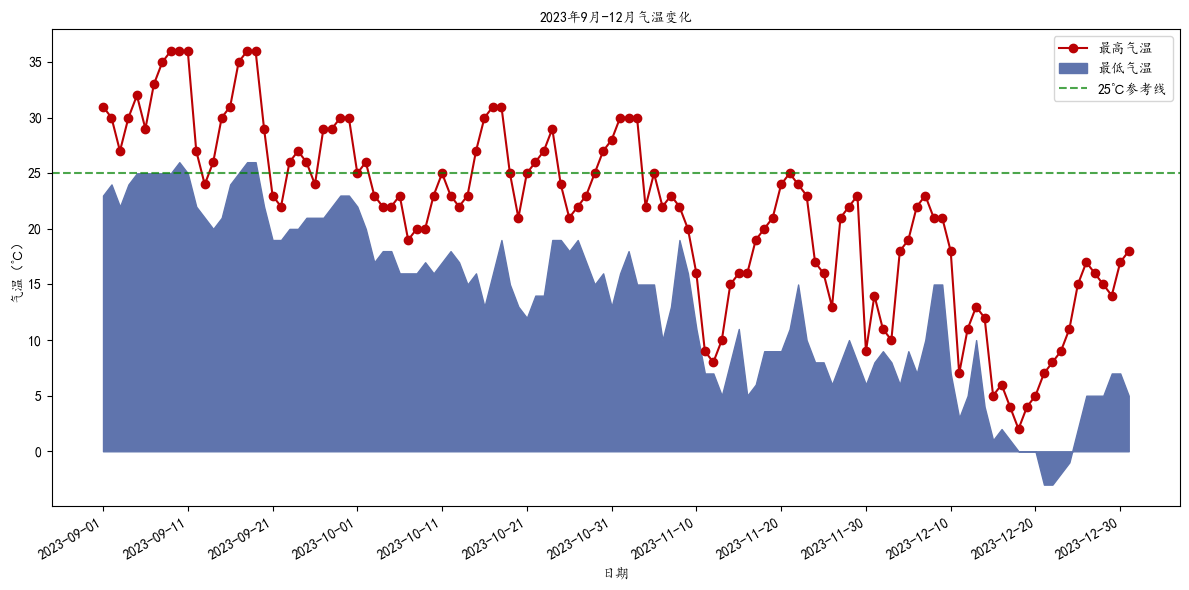

In [10]:
import matplotlib.pyplot as plt  
import pandas as pd  
import matplotlib.dates as mdates  
from matplotlib.font_manager import FontProperties  
  
import matplotlib.font_manager as fm
# 设置字体路径
font_path = r'../simkai.ttf'  # Windows示例
 
# 加载字体并设置
font_prop = fm.FontProperties(fname=font_path)
plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['axes.unicode_minus'] = False
  
# 从CSV文件读取数据  
df = pd.read_csv('气温数据.csv')  
print(df)
# 转换日期格式  
df['日期'] = pd.to_datetime(df['日期'])  
  
# 提取温度数值（去除℃符号并转换为数值类型）  
df['最高气温'] = df['最高气温'].str.rstrip('℃').astype(int)  
df['最低气温'] = df['最低气温'].str.rstrip('℃').astype(int)  
  
# 设置图表大小  
plt.figure(figsize=(12, 6), dpi=100)  
  
# 绘制最高气温折线图  
plt.plot(df['日期'], df['最高气温'], label='最高气温', color='#BA0104', marker='o')  
  
# 绘制最低气温面积图  
# plt.fill_between(df['日期'], df['最低气温'], color='#002fff', alpha=0.3, label='最低气温')  
plt.fill_between(df['日期'], df['最低气温'], color='#5F74AD', label='最低气温')  
# 添加25℃参考线（红色虚线）
plt.axhline(y=25, color='green', linestyle='--', linewidth=1.5, alpha=0.7, label='25℃参考线')
# 设置横坐标刻度（每10天显示一个点）  
date_format = mdates.DateFormatter('%Y-%m-%d')  
plt.gca().xaxis.set_major_formatter(date_format)  
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=10))  
plt.gcf().autofmt_xdate()  # 自动旋转横坐标标签  
  
# 添加标题和标签  
plt.title('2023年9月-12月气温变化', fontproperties=font_prop)  
plt.xlabel('日期', fontproperties=font_prop)  
plt.ylabel('气温（℃）', fontproperties=font_prop)  
plt.legend(prop=font_prop)  
  
# 自动调整布局  
plt.tight_layout()  
  
# 显示图形  
plt.show()

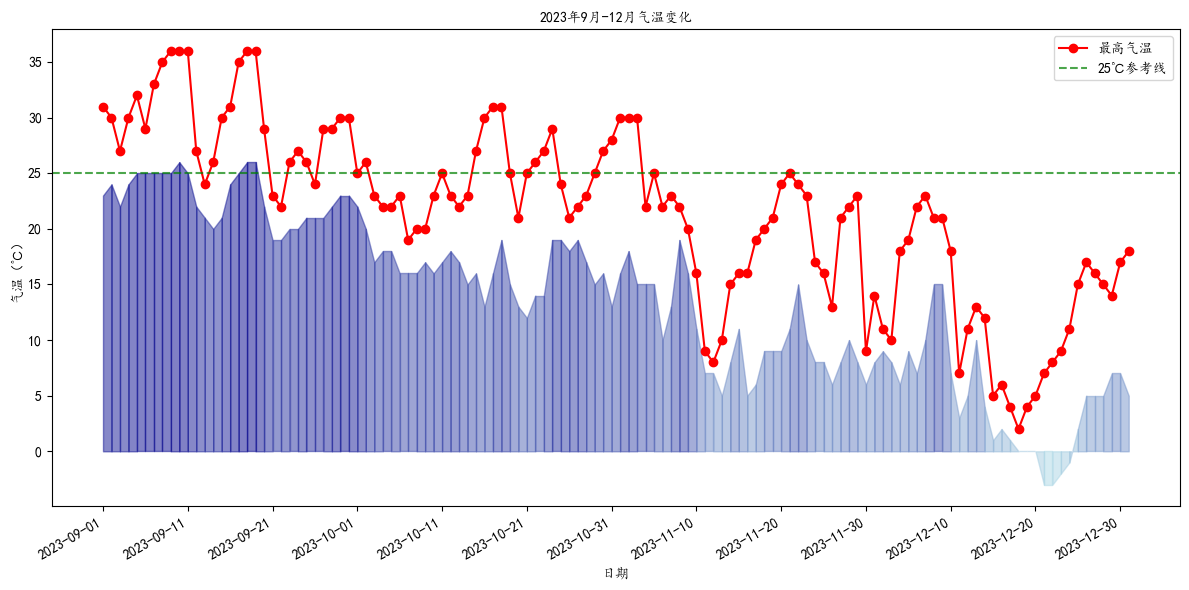

In [3]:
import matplotlib.pyplot as plt  
import pandas as pd  
import matplotlib.dates as mdates  
from matplotlib.colors import LinearSegmentedColormap, Normalize
import matplotlib.font_manager as fm

# 设置字体路径（替换为你的字体路径）
font_path = r'../simkai.ttf'  # Windows示例
font_prop = fm.FontProperties(fname=font_path)
plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['axes.unicode_minus'] = False

# 从CSV文件读取数据  
df = pd.read_csv('气温数据.csv')  

# 转换日期格式  
df['日期'] = pd.to_datetime(df['日期'])  

# 提取温度数值（去除℃符号并转换为数值类型）  
df['最高气温'] = df['最高气温'].str.rstrip('℃').astype(int)  
df['最低气温'] = df['最低气温'].str.rstrip('℃').astype(int)  

# 设置图表大小  
plt.figure(figsize=(12, 6), dpi=100)  

# 绘制最高气温折线图  
plt.plot(df['日期'], df['最高气温'], label='最高气温', color='red', marker='o')  

# 创建渐变色（从浅蓝到深蓝）
cmap = LinearSegmentedColormap.from_list('blue_gradient', ['#ADD8E6', '#00008B'])

# 归一化最低气温值，用于颜色映射
norm = Normalize(vmin=df['最低气温'].min(), vmax=df['最低气温'].max())

# 绘制最低气温渐变色面积图（根据y值渐变）
for i in range(len(df['日期']) - 1):
    # 使用 .iloc 确保按位置索引
    y_values = df['最低气温'].iloc[i:i+2].values
    # 取当前段的最低气温平均值作为颜色依据
    color_value = norm((y_values[0] + y_values[1]) / 2)
    plt.fill_between(
        df['日期'].iloc[i:i+2],  # x 值
        y_values,               # y 值
        color=cmap(color_value), # 颜色
        alpha=0.5
    )

# 添加25℃参考线（绿色虚线）
plt.axhline(y=25, color='green', linestyle='--', linewidth=1.5, alpha=0.7, label='25℃参考线')

# 设置横坐标刻度（每10天显示一个点）  
date_format = mdates.DateFormatter('%Y-%m-%d')  
plt.gca().xaxis.set_major_formatter(date_format)  
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=10))  
plt.gcf().autofmt_xdate()  # 自动旋转横坐标标签  

# 添加标题和标签  
plt.title('2023年9月-12月气温变化', fontproperties=font_prop)  
plt.xlabel('日期', fontproperties=font_prop)  
plt.ylabel('气温（℃）', fontproperties=font_prop)  
plt.legend(prop=font_prop)  

# 自动调整布局  
plt.tight_layout()  

# 显示图形  
plt.show()

             日期 大棚内最高气温 大棚内最低气温
0      2023/9/1     36℃     28℃
1      2023/9/2     35℃     29℃
2      2023/9/3     32℃     27℃
3      2023/9/4     35℃     29℃
4      2023/9/5     37℃     30℃
..          ...     ...     ...
117  2023/12/27     21℃     10℃
118  2023/12/28     20℃     10℃
119  2023/12/29     19℃     12℃
120  2023/12/30     22℃     12℃
121  2023/12/31     23℃     10℃

[122 rows x 3 columns]


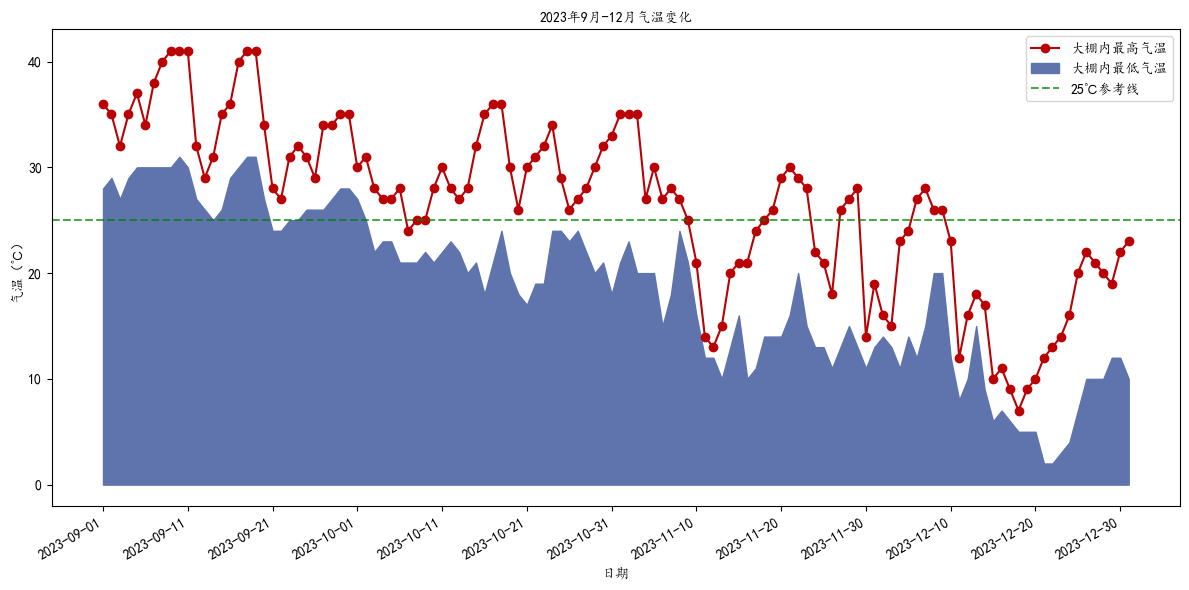

In [11]:
import matplotlib.pyplot as plt  
import pandas as pd  
import matplotlib.dates as mdates  
from matplotlib.font_manager import FontProperties  
  
import matplotlib.font_manager as fm
# 设置字体路径
font_path = r'../simkai.ttf'  # Windows示例
 
# 加载字体并设置
font_prop = fm.FontProperties(fname=font_path)
plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['axes.unicode_minus'] = False
  
# 从CSV文件读取数据  
df = pd.read_csv('大棚气温数据.csv')  
print(df)
# 转换日期格式  
df['日期'] = pd.to_datetime(df['日期'])  
  
# 提取温度数值（去除℃符号并转换为数值类型）  
df['大棚内最高气温'] = df['大棚内最高气温'].str.rstrip('℃').astype(int)  
df['大棚内最低气温'] = df['大棚内最低气温'].str.rstrip('℃').astype(int)  
  
# 设置图表大小  
plt.figure(figsize=(12, 6), dpi=100)  
  
# 绘制最高气温折线图  
plt.plot(df['日期'], df['大棚内最高气温'], label='大棚内最高气温', color='#BA0104', marker='o')  
  
# 绘制最低气温面积图  
# plt.fill_between(df['日期'], df['最低气温'], color='#002fff', alpha=0.3, label='最低气温')  
plt.fill_between(df['日期'], df['大棚内最低气温'], color='#5F74AD', label='大棚内最低气温')  
# 添加25℃参考线（红色虚线）
plt.axhline(y=25, color='green', linestyle='--', linewidth=1.5, alpha=0.7, label='25℃参考线')
# 设置横坐标刻度（每10天显示一个点）  
date_format = mdates.DateFormatter('%Y-%m-%d')  
plt.gca().xaxis.set_major_formatter(date_format)  
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=10))  
plt.gcf().autofmt_xdate()  # 自动旋转横坐标标签  
  
# 添加标题和标签  
plt.title('2023年9月-12月气温变化', fontproperties=font_prop)  
plt.xlabel('日期', fontproperties=font_prop)  
plt.ylabel('气温（℃）', fontproperties=font_prop)  
plt.legend(prop=font_prop)  
  
# 自动调整布局  
plt.tight_layout()  
  
# 显示图形  
plt.show()

In [27]:
from pyecharts.charts import Line
from pyecharts import options as opts
import pandas as pd

# 读取CSV文件（请替换为实际文件路径）
df = pd.read_csv('气温数据.csv')

# 数据预处理
df['日期'] = pd.to_datetime(df['日期'])
df['最高气温'] = df['最高气温'].str.replace('℃', '').astype(int)
df['最低气温'] = df['最低气温'].str.replace('℃', '').astype(int)

# 转换为列表格式供pyecharts使用
dates = df['日期'].dt.strftime('%Y/%m/%d').tolist()
high_temps = df['最高气温'].tolist()
low_temps = df['最低气温'].tolist()

# 创建图表对象
line = Line()

# 添加X轴
line.add_xaxis(xaxis_data=dates)

# 添加最高气温折线
line.add_yaxis(
    series_name="最高气温",
    y_axis=high_temps,
    symbol="circle",
    symbol_size=8,
    color="#c23531",
    linestyle_opts=opts.LineStyleOpts(width=3)
)

# 添加最低气温面积图（带渐变）
line.add_yaxis(
    series_name="最低气温",
    y_axis=low_temps,
    is_smooth=True,
    symbol=None,
    areastyle_opts=opts.AreaStyleOpts(
        opacity=0.3,
        color={
            "type": "linear",
            "x": 0,
            "y": 0,
            "x2": 0,
            "y2": 1,
            "colorStops": [{
                "offset": 0,
                "color": "#86CCED"  # 浅蓝
            }, {
                "offset": 1,
                "color": "#493A82"  # 深蓝
            }]
        }
    ),
    linestyle_opts=opts.LineStyleOpts(width=0)  # 隐藏轮廓线
)

# 添加20℃参考线
line.set_global_opts(
    title_opts=opts.TitleOpts(title="气温变化图"),
    visualmap_opts=opts.VisualMapOpts(
        is_show=False,
        type_="continuous",
        dimension=1,
        min_=min(low_temps),
        max_=max(low_temps),
        range_color=["#86CCED", "#493A82"]
    ),
    yaxis_opts=opts.AxisOpts(
        name="气温(℃)",
        axislabel_opts=opts.LabelOpts(formatter="{value} ℃")
    ),
    xaxis_opts=opts.AxisOpts(
        name="日期",
        boundary_gap=False,
        axislabel_opts=opts.LabelOpts(rotate=45)
    ),
    tooltip_opts=opts.TooltipOpts(trigger="axis"),
    datazoom_opts=[opts.DataZoomOpts()]
)

# 添加标记线
line.extend_axis(
    yaxis=opts.AxisOpts()
).set_series_opts(
    markline_opts=opts.MarkLineOpts(
        data=[opts.MarkLineItem(y=20, name="20℃参考线")],
        symbol=["none", "none"],
        label_opts=opts.LabelOpts(position="end", formatter="{b}"),
        linestyle_opts=opts.LineStyleOpts(
            type_="dashed", 
            color="#999",
            width=1.5
        )
    )
)

# 生成HTML文件
line.render("temperature_chart.html")


'E:\\pythonProject\\数据可视化\\折线图\\temperature_chart.html'